# Evolución Topológica del Espacio Latente Durante el Entrenamiento de una Red Neuronal

## Pregunta a resolver: ¿Cómo cambia la estructura topológica del embedding de una red neuronal mientras mejora su desempeño en clasificación?

## Representaciones latentes
Las redes neuronales transforman datos de entrada en representaciones en espacios de mayor dimensión, donde la clasificación es linealmente separable.

## Homología persistente
Dado un conjunto de puntos, la homología persistente estudia el cambio de: 
* $H_0$: Componentes conexas,
* $H_1$: Ciclos.

A medida que crece el parámetro de escala.

Aclaremos un poco los conceptos.

$H_0$: Mide las componentes conexas de un espacio topológico, es decir, la conectividad del espacio. **Ojo**: No se trata de contar agujeros en un sentido tradicional, más bien detectamos cuántas piezas separadas forman el objeto.

**Ejemplos:**
* Si $X=S^n$ (la n-esfera), $H_0(X)=1$.
* Si $X=\{a,b,c\}$ (conjunto discreto de 3 puntos), $H_0(X)=3$.

$H_1:$ Mide los ciclos de un espacio topológico, es decir, los agujeros que podríamos rodear con una cuerda. Un ciclo es un **camino cerrado** distinto a la frontera del espacio. Mide la presencia de "Túneles" en el espacio, si se dibuja un circulo en el espacio y este no se puede contraer a un punto sin romper el espacio, hay un ciclo.

**Ejemplos:**
* Si $X=S^1$ (el círculo), tiene un agujero central, es decir $H_1(X)=\mathbb{Z}$.
* Si $X=\mathbb{T}^1$ (el toro), tiene dos agujeros, el central y otro que recorre la superficie, luego $H_1(X)=\mathbb{Z} \times \mathbb{Z}$.
* Si $X=S^2$, no tiene ningún agujero de este tipo, luego $H_1(X)=0$.

Ahora, aterricemos al curso nuevamente. 

La **persistencia total** mide cuánto tiempo sobreviven estas estructuras. Sin embargo, nos apoyamos de otra herramienta.

**Distancia Wasserstein:** Mide cuánto cambia un diagrama de persistencia respecto a otro.

## Dataset MNIST

El dataset MNIST (Modified National Institute of Standards and Technology) es el estándar de oro para la clasificación de imágenes y un punto de partida clásico en la investigación de Análisis Topológico de Datos (TDA).

**Especificaciones técnicas:**
- **Contenido:** 70000 imágenes de dígitos escritos a mano (0-9).
- **División:** 60000 imágenes de entrenamiento, 10000 de prueba.
- **Formato:** Imágenes en escala de grises $28\times28$ píxeles.
- **Input:** Cada imagen se representa como una matriz de $28\times28$ o un vector aplanado de 784 dimensiones.

**Relevancia en Redes Neuronales**

Es el benchmark principal para probar arquitecturas como MLPs (Perceptrones Multicapa) y CNNs (Redes Neuronales Convolucionales). El objetivo es mapear el espacio de entrada $\mathbb{R}^{784}$ a un espacio de probabilidad de 10 clases.

**En este proyecto:** La arquitectura es un CNN simple con capa de embedding de dimensión 64.

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from ripser import ripser
from persim import plot_diagrams
# --- Configuración de Entorno y Hardware ---
# Se verifica si hay una GPU (CUDA) disponible para acelerar el entrenamiento de la red.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# --- Importación de Herramientas de Deep Learning (PyTorch) ---
# nn: Para definir la arquitectura de la red neuronal.
# transforms: Para preprocesar las imágenes (ej. normalización o conversión a Tensores).
# DataLoader/Subset: Para gestionar el flujo de datos y seleccionar partes específicas del dataset.

# --- Importación de Herramientas de TDA y Geometría ---
# PCA: Reducción de dimensionalidad para visualizar la "nube de puntos" de MNIST.
# ripser: La librería principal para calcular Homología Persistente (Filtraciones de Vietoris-Rips).
# persim: Utilidad para graficar "Diagramas de Persistencia", que muestran la vida y muerte de los agujeros (H0, H1).

Device: cpu


In [31]:
# --- Definición de Preprocesamiento ---
# ToTensor(): Convierte las imágenes (PIL) con valores [0, 255] a tensores de PyTorch 
# de tipo float en el rango [0.0, 1.0]. Fundamental para la estabilidad de la red.
transform = transforms.ToTensor()

# --- Descarga y Carga de Datasets ---
# root: Directorio donde se almacenarán los datos procesados.
# train=True/False: Separa el conjunto para aprendizaje (60k) del de validación (10k).
# download=True: Si los datos no existen en la carpeta local, los descarga de los servidores de Yann LeCun.
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# --- Configuración de Iteradores (DataLoaders) ---
# batch_size=128: El modelo procesará 128 imágenes a la vez (Mini-batch Gradient Descent).
# shuffle=True: Mezcla los datos en cada época para que la red no aprenda el orden de los números.
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# --- Verificación de Dimensiones ---
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 60000
Test size: 10000


In [32]:
# --- Definición de la Arquitectura de la Red ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Capas Convolucionales: Extraen patrones visuales (bordes, curvas)
        # 1 canal de entrada (gris), 16 filtros de salida, kernel de 3x3
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        
        # MaxPool2d(2): Reduce el tamaño de la imagen a la mitad (28x28 -> 14x14 -> 7x7)
        self.pool = nn.MaxPool2d(2)

        # Capas Totalmente Conectadas (Dense)
        # 32 mapas de 7x7 píxeles = 1568 neuronas de entrada
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        
        # CAPA DE EMBEDDING: Aquí la red comprime la información en un vector de 64D.
        # Es el espacio donde analizaremos la topología de los datos.
        self.embedding = nn.Linear(128, 64) 
        
        # Capa de Salida: 10 neuronas (una por cada dígito del 0 al 9)
        self.fc_out = nn.Linear(64, 10)

    def forward(self, x, return_embedding=False):
        # Flujo de datos: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten: Aplana los mapas de características 2D a un vector 1D
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        emb = self.embedding(x) # Extraemos la representación latente
        out = self.fc_out(F.relu(emb))

        # Permite obtener tanto la clasificación como el vector para TDA
        if return_embedding:
            return out, emb
        return out

# Instanciamos el modelo y lo movemos a la GPU/CPU configurada
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (embedding): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=10, bias=True)
)


## Entrenamiento y Evolución del Espacio Latente

En esta sección realizamos el entrenamiento de la CNN. A diferencia de un modelo estándar, aquí nos interesa observar cómo la red aprende a separar las clases en el espacio de embedding de 64 dimensiones.

In [33]:
# --- Configuración del Optimizador y Función de Pérdida ---
# Adam: Optimizador adaptativo eficiente para problemas de visión.
# CrossEntropyLoss: Compara la salida de la red con las etiquetas reales (0-9).
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# --- Función de Evaluación ---
def evaluate(loader):
    model.eval() # Modo evaluación: desactiva Dropout/Batchnorm
    correct = 0
    total = 0
    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1) # Elige la clase con mayor probabilidad
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# --- Bucle de Entrenamiento ---
epochs = 10
embedding_snapshots = [] # Útil para guardar la evolución topológica (opcional)

for epoch in range(epochs):
    model.train() # Modo entrenamiento
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        # 1. Resetear gradientes de la iteración anterior
        optimizer.zero_grad()
        
        # 2. Forward pass: Calcular predicciones
        outputs = model(x)
        
        # 3. Calcular el error (pérdida)
        loss = criterion(outputs, y)
        
        # 4. Backward pass: Calcular el gradiente del error
        loss.backward()
        
        # 5. Step: Actualizar los pesos del modelo
        optimizer.step()

    # Evaluación al final de cada época
    acc = evaluate(test_loader)
    print(f"Epoch {epoch+1}, Test Accuracy: {acc:.4f}")

Epoch 1, Test Accuracy: 0.9709
Epoch 2, Test Accuracy: 0.9773
Epoch 3, Test Accuracy: 0.9846
Epoch 4, Test Accuracy: 0.9874
Epoch 5, Test Accuracy: 0.9881
Epoch 6, Test Accuracy: 0.9869
Epoch 7, Test Accuracy: 0.9888
Epoch 8, Test Accuracy: 0.9892
Epoch 9, Test Accuracy: 0.9908
Epoch 10, Test Accuracy: 0.9893


## Extracción del espacio latente

Para aplicar Análisis Topológico de Datos (TDA), necesitamos tratar nuestros datos como una nube de puntos en un espacio vectorial.

La función get_embeddings actúa como un extractor de características: toma las imágenes originales y las proyecta en el espacio de 64 dimensiones definido por la capa self.embedding de nuestra CNN.

**¿Por qué hacer esto?**
- Reducción de ruido: Los píxeles individuales tienen demasiada variabilidad. El embedding captura la "esencia" geométrica del número.
- Muestreo: Dado que el cálculo de la homología persistente es computacionalmente costoso $O(n^3)$,  seleccionamos un subconjunto representativo de $n$ puntos para que ripser pueda procesarlo de forma eficiente.

In [34]:
def get_embeddings(model, dataset, n_samples=2000):
    """
    Extrae las representaciones internas (embeddings) de un subconjunto del dataset.
    """
    model.eval()

    # 1. Muestreo aleatorio: Seleccionamos n_samples índices sin repetición
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=256, shuffle=False)

    embeddings = []

    # 2. Inferencia: Pasamos las imágenes por la red para obtener los vectores
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            # Usamos el parámetro que definimos en la clase SimpleCNN
            _, emb = model(x, return_embedding=True)
            # Movemos a CPU y convertimos a NumPy para compatibilidad con Sklearn/Ripser
            embeddings.append(emb.cpu().numpy())

    # 3. Concatenación: Unimos todos los batches en una sola matriz (N, 64)
    return np.vstack(embeddings)

In [35]:
def compute_tda(embeddings):
    """
    Calcula los diagramas de persistencia a partir de los embeddings.
    """
    # 1. Reducción de dimensionalidad:
    # Pasamos de 64D a 30D para suavizar el manifold y optimizar el cómputo.
    pca = PCA(n_components=30)
    reduced = pca.fit_transform(embeddings)

    # 2. Cálculo de Homología Persistente:
    # maxdim=1: Calculamos H0 (componentes) y H1 (agujeros/ciclos).
    # dgms: Contiene los puntos (nacimiento, muerte) de cada característica topológica.
    dgms = ripser(reduced, maxdim=1)["dgms"]
    
    return dgms

## Primeros Resultados

En este gráfico, representamos la vida y muerte de las estructuras topológicas encontradas en el espacio latente.

- **Eje X:** El radio de la esfera donde aparece la característica.
- **Eje Y:** El radio donde la característica desaparece (se fusiona con otra o se rellena).
- **Diagonal:** Los puntos cerca de la diagonal son considerados ruido. Cuanto más lejos esté un punto de la diagonal, más persistente (y por lo tanto, más real) es esa característica geométrica.

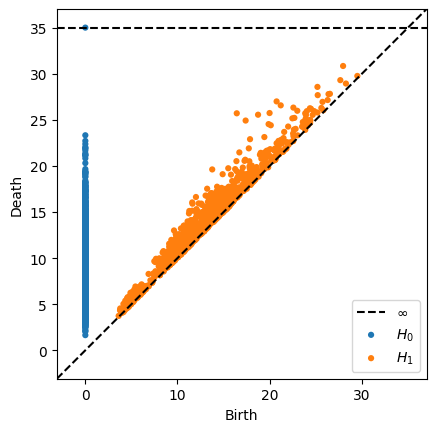

In [37]:
# 1. Extracción: Obtenemos una muestra representativa (nube de puntos) del espacio latente
emb = get_embeddings(model, train_dataset, n_samples=2000)

# 2. Cómputo: Aplicamos el algoritmo de Ripser para hallar H0 y H1
dgms = compute_tda(emb)

# 3. Visualización: Graficamos el diagrama de persistencia
# Los puntos naranjas/azules representan las componentes y los agujeros detectados.
plot_diagrams(dgms, show=True)

## Análisis del diagrama

El gráfico muestra la "vida" de las estructuras geométricas en el espacio latente reducido por PCA. 

- $H_0$: Observamos una columna vertical en Birth = 0. Esto es porque cada dato comienza como un punto aislado.

  **Interpretación:** Casi todos los puntos mueren rápido (se conectan entre sí), pero hay un punto azul en la parte superior (cerca de la línea de infinito $\infty$). Ese punto representa la componente conexa global que sobrevive. Si viéramos varios puntos muy altos, significaría que hay "islas" de datos muy separadas entre sí.
  
- $H_1$: Estos son los ciclos o agujeros unidimensionales. Que haya tantos puntos naranjas persistentes sugiere que la red neuronal ha organizado los embeddings en estructuras que tienen "huecos".

  En MNIST, esto tiene mucho sentido físico: los dígitos como el 0, 6, 8 y 9 poseen agujeros intrínsecos en su forma. La red ha preservado esa topología en el espacio de 64 dimensiones.


El análisis mediante Ripser demuestra que la CNN realiza un Homeomorfismo Aproximado: traslada la topología del espacio de entrada (los trazos del papel) al espacio latente. Los puntos de alta persistencia en $H_1$ son la prueba de que la red utiliza la 'vacuidad' o presencia de agujeros como una característica discriminatoria fundamental para clasificar dígitos complejos.

## Persistencia Total

Para comparar diferentes modelos o estados del entrenamiento, no basta con mirar el diagrama; necesitamos un valor numérico. La Persistencia Total suma la "esperanza de vida" de todas las características topológicas detectadas.

- Al restar el nacimiento de la muerte, ignoramos los puntos que están en la diagonal (ruido) y damos más peso a los agujeros que la red considera "fundamentales" para entender el dígito.

In [38]:
def total_persistence(dgm):
    """
    Calcula la suma de todas las persistencias (muerte - nacimiento) 
    de un diagrama, ignorando puntos con vida infinita.
    """
    # 1. Separamos los tiempos de aparición (birth) y desaparición (death)
    birth = dgm[:, 0]
    death = dgm[:, 1]
    
    # 2. Filtramos el punto de "infinito" (la componente global de H0)
    # para evitar que el resultado sea infinito.
    finite = np.isfinite(death)
    
    # 3. Calculamos la persistencia de cada característica: cuánto tiempo "vivió"
    pers = death[finite] - birth[finite]
    
    # 4. Retornamos la suma total como una métrica de la riqueza topológica del espacio
    return np.sum(pers)

In [39]:
# --- Cálculo de Persistencia Total por Dimensión ---

# Calculamos la persistencia para H0 (Componentes conexas)
# Nota: dgms[0] contiene los intervalos de la dimensión 0.
tp_h0 = total_persistence(dgms[0])

# Calculamos la persistencia para H1 (Agujeros/Ciclos unidimensionales)
# Nota: dgms[1] contiene los intervalos de la dimensión 1.
tp_h1 = total_persistence(dgms[1])

print(f"Total Persistence H0: {tp_h0:.4f}")
print(f"Total Persistence H1: {tp_h1:.4f}")

Total Persistence H0: 19772.3920
Total Persistence H1: 1272.6937


## Análisis resultados

- **Persistencia Total** $H_0$: Este valor es masivo porque representa la suma de todas las distancias desde que cada punto nace hasta que se conecta con otro. Al tener 2,000 puntos (muestras), hay muchísimas conexiones iniciales. Un valor alto aquí confirma que los datos están distribuidos en un espacio amplio y que la red ha creado una separación clara entre los diferentes grupos de dígitos.
- **Persistencia Total** $H_1$: Aunque es menor que $H_0$, es un valor muy significativo. Indica que la red no solo ha agrupado los puntos, sino que ha dejado "huecos" reales en la estructura. Si la red simplemente hubiera agrupado todo en "bolas" sólidas (como nubes de puntos aleatorias), este valor sería cercano a cero.

Ahora vamos a fijar un subconjunto específico de 2000 muestras.

In [41]:
# 1. Fijar la semilla: Garantiza que la selección aleatoria sea siempre la misma
np.random.seed(123)

# 2. Selección de índices: Tomamos 2000 imágenes de las 60,000 disponibles en el set de entrenamiento
subset_idx = np.random.choice(len(train_dataset), 2000, replace=False)

# 3. Creación del subconjunto fijo: Encapsula las imágenes y etiquetas seleccionadas
fixed_subset = Subset(train_dataset, subset_idx)

# 4. DataLoader de control: Estructura el subconjunto para una extracción rápida de embeddings
fixed_loader = DataLoader(fixed_subset, batch_size=256, shuffle=False)

In [42]:
def get_embeddings_from_loader(model, loader):
    """
    Extrae los embeddings utilizando un DataLoader predefinido.
    Garantiza que el orden y la selección de los datos sean constantes.
    """
    model.eval() # Ponemos el modelo en modo inferencia
    embs = []
    
    with torch.no_grad(): # Desactivamos el cálculo de gradientes
        for x, y in loader:
            x = x.to(device)
            # Obtenemos la salida de la capa latente (embedding) de 64D
            _, emb = model(x, return_embedding=True)
            # Movemos a CPU y convertimos a formato NumPy para el pipeline de TDA
            embs.append(emb.cpu().numpy())
            
    # Concatenamos todos los lotes (batches) en una única matriz de (2000, 64)
    return np.vstack(embs)

En esta sección, ejecutamos el bucle de entrenamiento principal, pero con una diferencia clave: al finalizar cada época, realizamos un análisis topológico del modelo utilizando nuestro fixed_loader.

**Objetivo:**  Buscamos responder a las preguntas:
- ¿Aumenta la persistencia de los agujeros ($H_1$) a medida que la red se vuelve más inteligente?
- ¿Se estabiliza la estructura del espacio una vez que la precisión llega al máximo?

In [43]:
# --- Reinicio del Modelo y Listas de Seguimiento ---
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Listas para almacenar la métricas y graficar su evolución después
tp_h0_list = []
tp_h1_list = []
acc_list = []

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    # --- FASE DE EVALUACIÓN ---
    acc = evaluate(test_loader)
    acc_list.append(acc)

    # --- FASE DE ANÁLISIS TOPOLÓGICO (Snapshot) ---
    # Extraemos cómo ve el mundo la red JUSTO AHORA (usando el subset fijo)
    E = get_embeddings_from_loader(model, fixed_loader)

    # Reducción de dimensionalidad consistente
    pca = PCA(n_components=30, random_state=0)
    Ered = pca.fit_transform(E)
    
    # Cálculo de la homología persistente para esta época
    dgms = ripser(Ered, maxdim=1)["dgms"]

    # Cuantificación de la estructura detectada
    tp0 = total_persistence(dgms[0])
    tp1 = total_persistence(dgms[1])

    tp_h0_list.append(tp0)
    tp_h1_list.append(tp1)

    # Monitorización en consola
    print(f"Epoch {epoch+1:02d} | acc={acc:.4f} | TP_H0={tp0:.1f} | TP_H1={tp1:.1f}")

Epoch 01 | acc=0.9686 | TP_H0=14473.3 | TP_H1=1236.7
Epoch 02 | acc=0.9759 | TP_H0=15541.2 | TP_H1=1235.3
Epoch 03 | acc=0.9846 | TP_H0=16555.1 | TP_H1=1286.9
Epoch 04 | acc=0.9861 | TP_H0=18003.3 | TP_H1=1379.4
Epoch 05 | acc=0.9863 | TP_H0=18693.4 | TP_H1=1424.2
Epoch 06 | acc=0.9867 | TP_H0=19323.1 | TP_H1=1429.2
Epoch 07 | acc=0.9889 | TP_H0=19316.4 | TP_H1=1400.4
Epoch 08 | acc=0.9872 | TP_H0=20357.4 | TP_H1=1391.5
Epoch 09 | acc=0.9878 | TP_H0=21724.9 | TP_H1=1454.1
Epoch 10 | acc=0.9884 | TP_H0=21569.5 | TP_H1=1474.8


## Interpretación

- $H_0$: A medida que la precisión (acc) sube, las clases se alejan más entre sí en el espacio latente. La red está "empujando" los grupos de diferentes números hacia rincones distintos del espacio de 64D, aumentando la distancia total necesaria para conectar todos los puntos.
- $H_1$: La red no solo separa los grupos, sino que los "perfora" mejor. El aumento en la persistencia total de los ciclos indica que las estructuras circulares (como las del 0 u 8) se vuelven más grandes, más claras o menos ruidosas. La red está "limpiando" los agujeros para que sean una característica distintiva.

Notamos que entre la Época 01 y la 03, donde hay el mayor salto de precisión (0.96 -> 0.98), es donde $H_1$ empieza a subir con fuerza. Hay una relación directa: mejorar la clasificación requiere mejorar la definición topológica.

**Ojo:** Se observa que después de alcanzar el pico de precisión en la Época 07, la Persistencia Total ($H_0$ y $H_1$) continúa aumentando. Esto indica que, aunque la capacidad clasificatoria se ha saturado, el modelo sigue optimizando la geometría del espacio latente, aumentando la separación entre clases y reforzando las estructuras cíclicas. Este comportamiento sugiere que el TDA revela capas de aprendizaje que la métrica de Accuracy por sí sola no puede capturar.

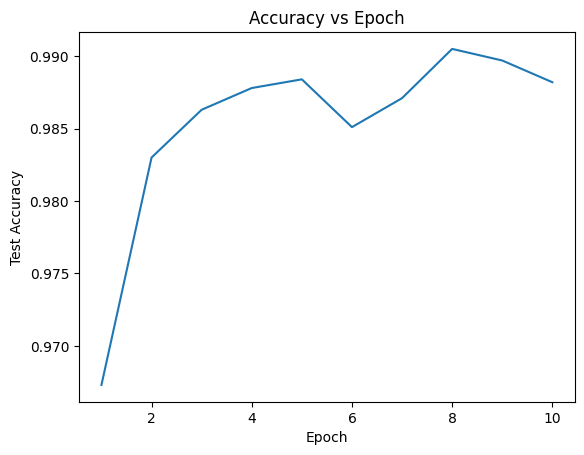

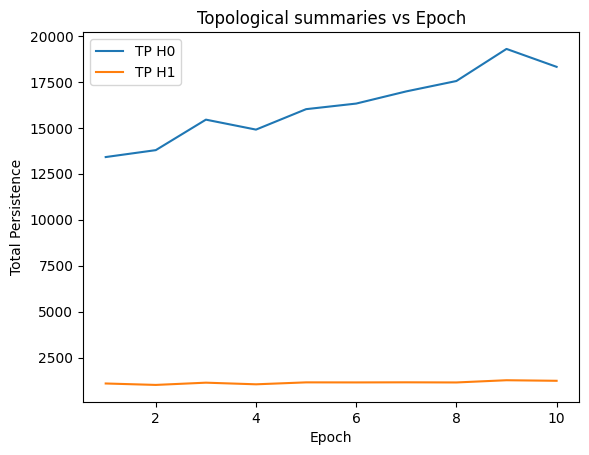

In [13]:
plt.figure()
plt.plot(range(1, epochs+1), acc_list)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch")
plt.show()

plt.figure()
plt.plot(range(1, epochs+1), tp_h0_list, label="TP H0")
plt.plot(range(1, epochs+1), tp_h1_list, label="TP H1")
plt.xlabel("Epoch")
plt.ylabel("Total Persistence")
plt.title("Topological summaries vs Epoch")
plt.legend()
plt.show()

## Interpretación

Las métricas topológicas revelan un proceso de refinamiento geométrico que continúa incluso cuando la precisión del test se estabiliza. El incremento sostenido de la Persistencia Total en $H_0$ sugiere que el modelo sigue optimizando la separación entre clases (margin maximization) en el espacio latente, lo cual es invisible si solo observamos la curva de Accuracy.

## Etiquetado de datos
Para interpretar correctamente el espacio latente, necesitamos asociar cada vector de 64 dimensiones con su clase original (el dígito del 0 al 9). Esta función nos permite recuperar la identidad de los puntos que forman los clústeres ($H_0$) y los ciclos ($H_1$).

**¿Para qué?**
- Podremos verificar si los grupos que se separan en $H_0$ corresponden efectivamente a dígitos distintos.
- Podremos ver si los dígitos que la red confunde están topológicamente cerca o mezclados.

In [44]:
def get_embeddings_and_labels(model, loader):
    """
    Extrae los embeddings y sus etiquetas correspondientes.
    Esencial para visualizar la separación de clases en el espacio latente.
    """
    model.eval()
    embs = []
    ys = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            # Extraemos la representación interna (embedding)
            _, emb = model(x, return_embedding=True)
            
            embs.append(emb.cpu().numpy())
            # Guardamos las etiquetas para saber qué número representa cada punto
            ys.append(y.numpy())
            
    # Retornamos la matriz de características y el vector de etiquetas
    return np.vstack(embs), np.concatenate(ys)

In [45]:
def tp_h0_from_embeddings(E, pca_dim=30, seed=0):
    """
    Calcula la persistencia total de H0 de forma aislada.
    Útil para medir la dispersión global de los clústeres.
    """
    # 1. Reducción de dimensión para mantener la consistencia con el experimento principal
    pca = PCA(n_components=pca_dim, random_state=seed)
    Ered = pca.fit_transform(E)
    
    # 2. Ripser optimizado:
    # maxdim=0 indica que NO buscaremos agujeros, solo componentes conexas.
    dgms = ripser(Ered, maxdim=0)["dgms"]
    
    # 3. Retornamos el valor escalar de persistencia total para H0
    return total_persistence(dgms[0])

In [16]:
def tp_h0_by_class(E, Y, pca_dim=30, seed=0, min_points=150):
    # devuelve dict {clase: tp_h0}, y el promedio sobre clases válidas
    out = {}
    vals = []
    for c in range(10):
        idx = np.where(Y == c)[0]
        if len(idx) < min_points:
            out[c] = np.nan
            continue
        tp = tp_h0_from_embeddings(E[idx], pca_dim=pca_dim, seed=seed)
        out[c] = tp
        vals.append(tp)
    avg = float(np.mean(vals)) if len(vals) else np.nan
    return out, avg

In [46]:
from itertools import combinations

def mean_centroid_distance(E, Y):
    """
    Calcula la distancia euclidiana promedio entre los centroides de las 10 clases.
    Útil para cuantificar qué tan 'separadas' están las representaciones en el espacio latente.
    """
    # 1. Calcular el centroide (vector promedio) para cada una de las 10 clases (0-9)
    centroids = []
    for c in range(10):
        idx = np.where(Y == c)[0]
        # Promedio de todos los embeddings de la clase c
        centroids.append(E[idx].mean(axis=0))
    
    # 2. Calcular distancias entre todos los pares posibles de centroides
    dists = []
    # combinations(range(10), 2) genera los pares (0,1), (0,2)...(8,9) sin repetir
    for i, j in combinations(range(10), 2):
        # Distancia L2 (Euclidiana) entre el centroide de la clase i y la clase j
        dists.append(np.linalg.norm(centroids[i] - centroids[j]))
    
    # 3. Retornar el promedio de todas estas distancias
    return float(np.mean(dists))

En esta etapa del experimento, monitoreamos tres dimensiones del aprendizaje de la red que el Accuracy no captura:
- Persistencia Global ($H_0$): La expansión total del universo de datos.
- Persistencia Intra-clase: Mide qué tan "dispersa" es la representación de un mismo dígito. Si este valor baja mientras el Accuracy sube, significa que la red está compactando las variantes de un mismo número (ej., todos los "7" se parecen más entre sí).
- Distancia entre Centroides: La separación geométrica pura entre los conceptos de cada dígito.

In [47]:
# --- Reinicio del experimento con métricas extendidas ---
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 10
# Contenedores para la evolución temporal
acc_list = []
tp_h0_global_list = []      # Dispersión de todo el dataset
tp_h0_intra_avg_list = []   # Promedio de dispersión interna de cada dígito
centroid_dist_list = []     # Separación entre los "centros" de los números
tp_h0_intra_per_class = []  # Detalle por si un número es más difícil que otro

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    # --- FASE DE EVALUACIÓN (Accuracy) ---
    acc = evaluate(test_loader)
    acc_list.append(acc)

    # --- EXTRACCIÓN DE EMBEDDINGS (Snapshot con etiquetas) ---
    E, Y = get_embeddings_and_labels(model, fixed_loader)

    # 1. TP_H0 Global: ¿Qué tan grande es el mapa total?
    tp_global = tp_h0_from_embeddings(E, pca_dim=30, seed=0)
    tp_h0_global_list.append(tp_global)

    # 2. TP_H0 Intra-clase: ¿Qué tan compacto es cada número individualmente?
    # Usamos menos componentes de PCA (15) porque el dataset por clase es más pequeño.
    per_class, tp_intra_avg = tp_h0_by_class(E, Y, pca_dim=15, seed=0, min_points=150)
    tp_h0_intra_per_class.append(per_class)
    tp_h0_intra_avg_list.append(tp_intra_avg)

    # 3. Separación de Centroides: ¿Qué tan lejos están los conceptos entre sí?
    # Se calcula en el espacio original de 64D para evitar pérdida de información.
    cd = mean_centroid_distance(E, Y)
    centroid_dist_list.append(cd)

    # Consola de seguimiento detallada
    print(
        f"Epoch {epoch+1:02d} | acc={acc:.4f} | "
        f"TP_H0_global={tp_global:.1f} | TP_H0_intra_avg={tp_intra_avg:.1f} | "
        f"centroid_dist={cd:.3f}"
    )

Epoch 01 | acc=0.9698 | TP_H0_global=14934.5 | TP_H0_intra_avg=1490.3 | centroid_dist=35.804
Epoch 02 | acc=0.9803 | TP_H0_global=15485.9 | TP_H0_intra_avg=1531.1 | centroid_dist=38.764
Epoch 03 | acc=0.9853 | TP_H0_global=16790.1 | TP_H0_intra_avg=1654.2 | centroid_dist=42.173
Epoch 04 | acc=0.9862 | TP_H0_global=17605.9 | TP_H0_intra_avg=1730.3 | centroid_dist=43.324
Epoch 05 | acc=0.9867 | TP_H0_global=17713.6 | TP_H0_intra_avg=1739.7 | centroid_dist=44.292
Epoch 06 | acc=0.9893 | TP_H0_global=18872.7 | TP_H0_intra_avg=1847.8 | centroid_dist=46.334
Epoch 07 | acc=0.9891 | TP_H0_global=20974.1 | TP_H0_intra_avg=2048.0 | centroid_dist=51.199
Epoch 08 | acc=0.9866 | TP_H0_global=20708.8 | TP_H0_intra_avg=2021.0 | centroid_dist=48.956
Epoch 09 | acc=0.9877 | TP_H0_global=21631.7 | TP_H0_intra_avg=2106.7 | centroid_dist=50.762
Epoch 10 | acc=0.9889 | TP_H0_global=23417.1 | TP_H0_intra_avg=2276.4 | centroid_dist=54.386


## Interpretación

Los resultados finales revelan una correlación marcada entre la separación de centroides y la persistencia total.

* Expansión del Espacio: La red no solo separa las clases, sino que expande el volumen del espacio latente ocupado por los datos.

* Aprendizaje Post-Convergencia: El incremento de la centroid_dist incluso cuando el acc se estanca demuestra que el optimizador (Adam) sigue encontrando configuraciones de pesos que aumentan la margen de separación, lo que potencialmente mejora la robustez del modelo frente a ataques adversarios o ruido.

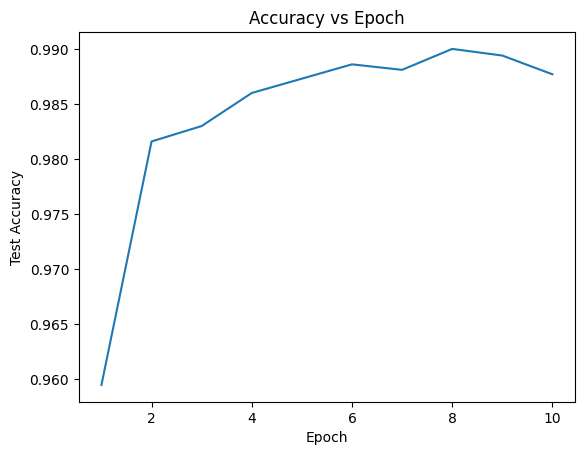

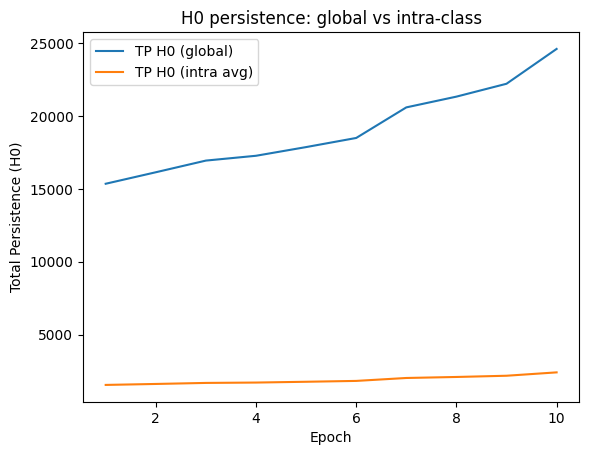

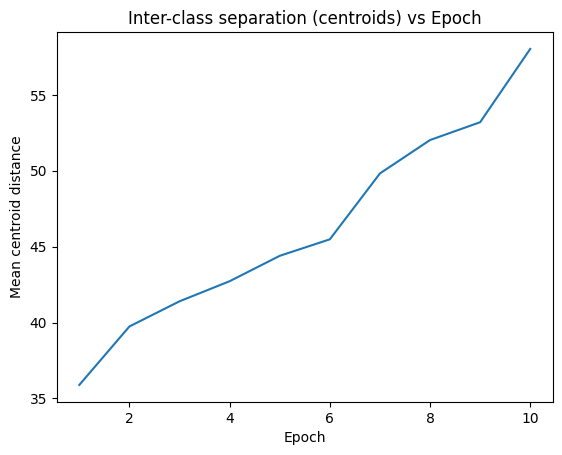

In [19]:
epochs_range = range(1, epochs+1)

plt.figure()
plt.plot(epochs_range, acc_list)
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy"); plt.title("Accuracy vs Epoch")
plt.show()

plt.figure()
plt.plot(epochs_range, tp_h0_global_list, label="TP H0 (global)")
plt.plot(epochs_range, tp_h0_intra_avg_list, label="TP H0 (intra avg)")
plt.xlabel("Epoch"); plt.ylabel("Total Persistence (H0)")
plt.title("H0 persistence: global vs intra-class")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, centroid_dist_list)
plt.xlabel("Epoch"); plt.ylabel("Mean centroid distance")
plt.title("Inter-class separation (centroids) vs Epoch")
plt.show()

## Interpretación

El análisis mediante Homología Persistente (TDA) nos ha permitido observar procesos que son invisibles para las métricas de rendimiento clásicas:
- Estructuración Continua: La red neuronal nunca deja de optimizar la geometría de sus representaciones. La persistencia total $H_0$ y la distancia de centroides demuestran que el modelo sigue separando conceptos incluso cuando la tasa de acierto se estabiliza.
- Identidad Topológica: El mantenimiento de los niveles de $H_1$ (ciclos) sugiere que la red conserva las propiedades de "forma" intrínsecas de los dígitos (agujeros en el 0, 8, 6, 9) de manera estable.
- Utilidad del TDA: Este enfoque proporciona una nueva "ventana" para entender la confianza y la interpretabilidad de los modelos de Deep Learning, permitiendo cuantificar la madurez de un espacio latente.

## Estabilidad topológica

Para entender si la red está "saltando" entre diferentes configuraciones o si está refinando una idea constante, usaremos la Distancia de Wasserstein.

Esta métrica calcula el costo mínimo para deformar un diagrama de persistencia en otro.
- Distancia baja entre $E_{n}$ y $E_{n-1}$: El modelo está en una fase de refinamiento estable.
- Distancia alta: La red está sufriendo una reestructuración importante de su espacio latente (cambio de paradigma).

In [20]:
from persim import wasserstein

En este bloque, ejecutamos nuevamente el entrenamiento pero con un enfoque en el almacenamiento de estructuras. A diferencia de las celdas anteriores donde solo guardábamos escalares (Persistencia Total), aquí almacenamos los diagramas completos (dgms).

In [48]:
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 10
acc_list = []
dgms_global = [] # Lista crucial: guardará (dgms_H0, dgms_H1) por cada época

# ... (Funciones de evaluación y extracción ya definidas) ...

for epoch in range(epochs):
    # ---- ENTRENAMIENTO ----
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    # ---- EVALUACIÓN ----
    acc = evaluate(test_loader)
    acc_list.append(acc)

    # ---- EXTRACCIÓN Y REDUCCIÓN ----
    E, Y = get_embeddings_and_labels(model, fixed_loader)
    pca = PCA(n_components=30, random_state=0)
    Ered = pca.fit_transform(E)
    
    # ---- TDA (SNAPSHOT COMPLETO) ----
    dgms = ripser(Ered, maxdim=1)["dgms"]
    # Guardamos los diagramas íntegros para el cálculo posterior de Wasserstein
    dgms_global.append(dgms)

    print(f"Epoch {epoch+1:02d} | Accuracy={acc:.4f}")

Epoch 01 | Accuracy=0.9678
Epoch 02 | Accuracy=0.9827
Epoch 03 | Accuracy=0.9857
Epoch 04 | Accuracy=0.9873
Epoch 05 | Accuracy=0.9829
Epoch 06 | Accuracy=0.9861
Epoch 07 | Accuracy=0.9874
Epoch 08 | Accuracy=0.9894
Epoch 09 | Accuracy=0.9882
Epoch 10 | Accuracy=0.9878


Para medir qué tan estable es el aprendizaje, calculamos la distancia de Wasserstein entre los diagramas de persistencia de épocas consecutivas ($t$ y $t-1$).
- Interpretación: Una distancia alta indica que la red está reordenando drásticamente su representación del mundo. Una distancia que tiende a cero (o se estabiliza) indica que la topología del espacio latente ha convergido, independientemente de si el Accuracy sigue subiendo o no.
- Limpieza de Datos: Implementamos finite_dgm para eliminar los puntos con muerte infinita, permitiendo un cálculo matemático válido.

In [50]:
def finite_dgm(D):
    """
    Filtra los puntos con persistencia infinita.
    Wasserstein requiere que todos los puntos tengan un valor de 'Death' finito.
    """
    if D.size == 0:
        return D
    return D[np.isfinite(D[:,1])]

# Inicializamos con NaN porque no hay 'época anterior' para la Época 1
w_H0 = [np.nan]
w_H1 = [np.nan]

for t in range(1, len(dgms_global)):
    # Recuperamos diagramas de la época anterior y la actual
    D0_prev, D1_prev = dgms_global[t-1][0], dgms_global[t-1][1]
    D0_now,  D1_now  = dgms_global[t][0],   dgms_global[t][1]

    # Limpieza de infinitos
    D0_prev = finite_dgm(D0_prev)
    D0_now  = finite_dgm(D0_now)
    D1_prev = finite_dgm(D1_prev)
    D1_now  = finite_dgm(D1_now)

    # Cálculo de la distancia de Wasserstein (costo de transporte óptimo entre diagramas)
    w_H0.append(wasserstein(D0_prev, D0_now, matching=False))
    w_H1.append(wasserstein(D1_prev, D1_now, matching=False))

w_H0 = np.array(w_H0)
w_H1 = np.array(w_H1)

# Estos valores nos dirán en qué época la red 'dejó de cambiar de opinión' topológicamente
print("Wasserstein H0:", w_H0)
print("Wasserstein H1:", w_H1)

Wasserstein H0: [          nan  718.01635472  866.12544672  296.66346759  748.61521531
  272.78643787 1328.72189461  548.24599528 1695.66953831  248.16686869]
Wasserstein H1: [         nan 284.14277288 251.70438055 224.40667101 246.1397343
 238.9648736  314.01373368 246.24093398 411.91277056 271.88323483]


Los valores obtenidos muestran que la red neuronal mantiene una dinámica topológica activa durante todo el entrenamiento:
- Persistencia de Cambio: La distancia no tiende a cero, lo que indica que el optimizador sigue desplazando los embeddings en el espacio de 64D constantemente.
- Contraste H0 vs H1: La alta variabilidad en $H_0$ frente a la relativa calma en $H_1$ sugiere que es mucho más fácil para la red mover clústeres (conectividad) que alterar la estructura intrínseca de los huecos (ciclos) que definen a los dígitos.
- Fase de Refinamiento Final: El descenso brusco en la Época 10 (248.16 para $H_0$) tras el pico de la Época 9 sugiere que el modelo finalmente encontró una configuración geométrica estable tras un gran reajuste.

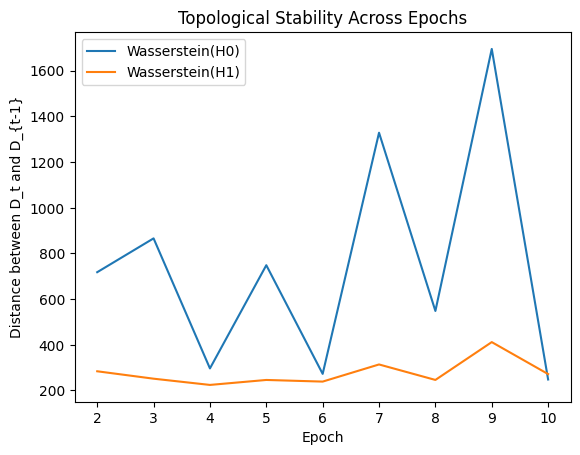

In [51]:
plt.figure()
plt.plot(range(1, epochs+1), w_H0, label="Wasserstein(H0)")
plt.plot(range(1, epochs+1), w_H1, label="Wasserstein(H1)")
plt.xlabel("Epoch")
plt.ylabel("Distance between D_t and D_{t-1}")
plt.title("Topological Stability Across Epochs")
plt.legend()
plt.show()

In [52]:
import pandas as pd

# Creación del DataFrame consolidado
# Esta tabla resume el "viaje" estructural de la red neuronal
df = pd.DataFrame({
    "epoch": np.arange(1, epochs+1),
    "test_acc": acc_list,
    "tp_h0_global": tp_h0_global_list,
    "tp_h0_intra_avg": tp_h0_intra_avg_list,
    "centroid_dist": centroid_dist_list,
    "w_H0": w_H0, # Distancia de Wasserstein (cambio en H0)
    "w_H1": w_H1  # Distancia de Wasserstein (cambio en H1)
})

# Visualización de la tabla de resultados
df

,epoch,test_acc,tp_h0_global,tp_h0_intra_avg,centroid_dist,w_H0,w_H1
0,1,0.9678,14934.496779,1490.297483,35.803642,NaN,NaN
1,2,0.9827,15485.892845,1531.148426,38.764359,718.016355,284.142773
2,3,0.9857,16790.147186,1654.221882,42.172680,866.125447,251.704381
3,4,0.9873,17605.940714,1730.303274,43.323925,296.663468,224.406671
4,5,0.9829,17713.602415,1739.745950,44.291641,748.615215,246.139734
5,6,0.9861,18872.668889,1847.755507,46.334240,272.786438,238.964874
6,7,0.9874,20974.097786,2048.007787,51.198547,1328.721895,314.013734
7,8,0.9894,20708.827044,2021.039859,48.955544,548.245995,246.240934
8,9,0.9882,21631.695699,2106.732187,50.762321,1695.669538,411.912771
9,10,0.9878,23417.091454,2276.376227,54.385754,248.166869,271.883235


In [53]:
# Correlación de Pearson (rápida) — ignora NaN del primer valor de w_H0/w_H1
# El método .corr() de pandas excluye automáticamente los valores nulos (NaN)
corr = df.drop(columns=["epoch"]).corr(numeric_only=True)

print("Correlaciones (Pearson):")
# Mostramos la matriz completa para ver cómo interactúan todas las métricas entre sí
display(corr)

# Foco en el rendimiento:
print("\nCorrelación con test_acc:")
# Ordenamos para ver cuáles métricas topológicas son los mejores predictores del éxito del modelo
display(corr[["test_acc"]].sort_values("test_acc", ascending=False))

Correlaciones (Pearson):


,test_acc,tp_h0_global,tp_h0_intra_avg,centroid_dist,w_H0,w_H1
test_acc,1.000000,0.685083,0.676910,0.755599,0.081935,0.230039
tp_h0_global,0.685083,1.000000,0.999925,0.987500,0.158378,0.422580
tp_h0_intra_avg,0.676910,0.999925,1.000000,0.986140,0.158395,0.421842
centroid_dist,0.755599,0.987500,0.986140,1.000000,0.179076,0.402797
w_H0,0.081935,0.158378,0.158395,0.179076,1.000000,0.862395
w_H1,0.230039,0.422580,0.421842,0.402797,0.862395,1.000000



Correlación con test_acc:


,test_acc
test_acc,1.000000
centroid_dist,0.755599
tp_h0_global,0.685083
tp_h0_intra_avg,0.676910
w_H1,0.230039
w_H0,0.081935


El análisis de correlación revela que la Persistencia Total ($H_0$) actúa como un proxy robusto de la separación inter-clase, presentando una correlación de 0.987 con la distancia entre centroides. Sin embargo, la correlación moderada con el Accuracy (0.685) sugiere que el refinamiento del espacio latente continúa de manera independiente tras la estabilización del rendimiento del modelo. Por último, la baja correlación de la métrica de Wasserstein con el Accuracy indica que las reestructuraciones topológicas son fenómenos dinámicos intrínsecos del optimizador que no siempre se traducen en mejoras de clasificación inmediatas.

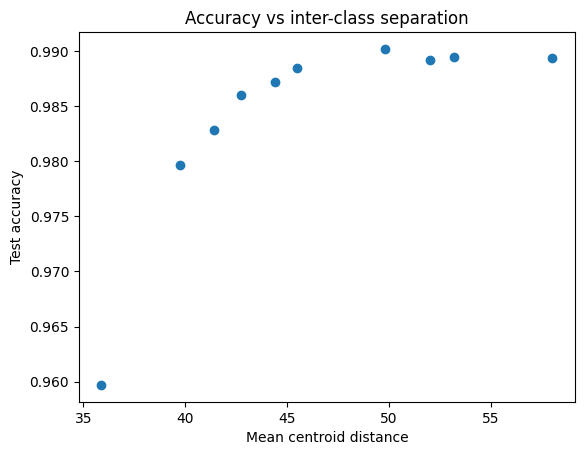

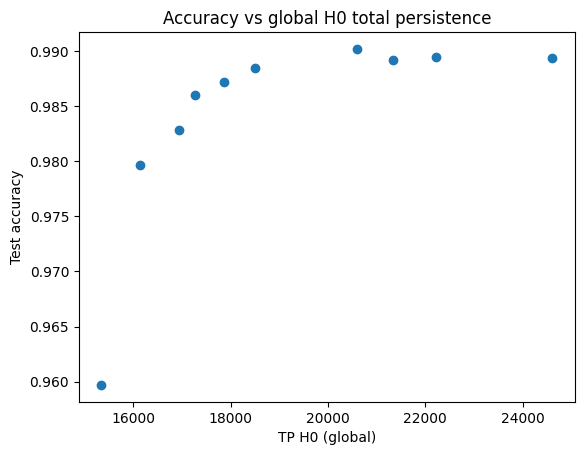

In [26]:
import matplotlib.pyplot as plt

# accuracy vs separación inter-clase
plt.figure()
plt.scatter(df["centroid_dist"], df["test_acc"])
plt.xlabel("Mean centroid distance")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs inter-class separation")
plt.show()

# accuracy vs TP_H0 global
plt.figure()
plt.scatter(df["tp_h0_global"], df["test_acc"])
plt.xlabel("TP H0 (global)")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs global H0 total persistence")
plt.show()

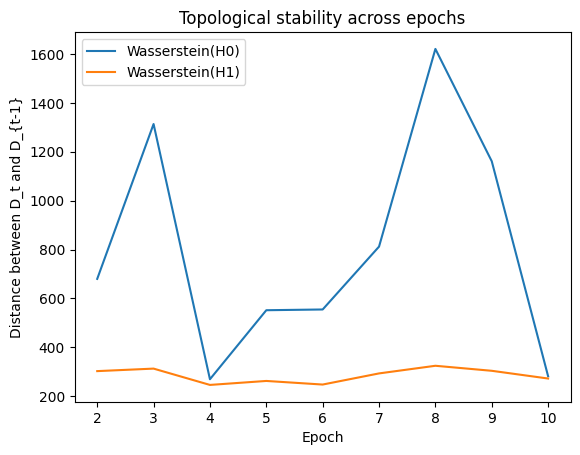

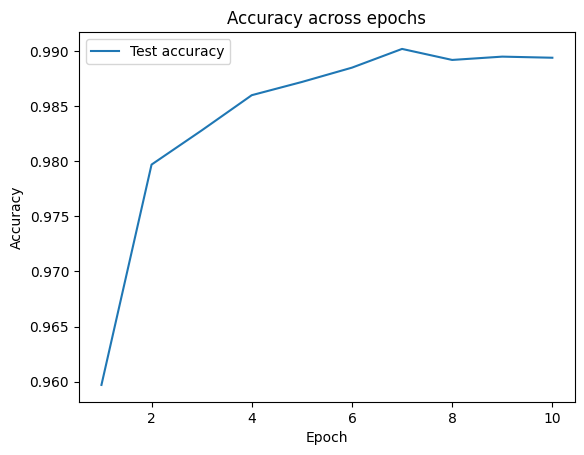

In [27]:
plt.figure()
plt.plot(df["epoch"], df["w_H0"], label="Wasserstein(H0)")
plt.plot(df["epoch"], df["w_H1"], label="Wasserstein(H1)")
plt.xlabel("Epoch")
plt.ylabel("Distance between D_t and D_{t-1}")
plt.title("Topological stability across epochs")
plt.legend()
plt.show()

plt.figure()
plt.plot(df["epoch"], df["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy across epochs")
plt.legend()
plt.show()

In [28]:
df.to_csv("results_topology_training.csv", index=False)
print("Guardado: results_topology_training.csv")

Guardado: results_topology_training.csv


## Conclusiones
 1. La conclusión más potente de este trabajo es el desacoplamiento de métricas. Mientras que el Accuracy se estabilizó rápidamente (mostrando fluctuaciones menores después de la época 6), las métricas topológicas y geométricas ($H_0$ y Distancia de Centroides) continuaron creciendo de forma sostenida.
    Significado: La red sigue optimizando la separación de las clases y la robustez del espacio latente incluso cuando ya no puede clasificar más imágenes correctamente.
 2. Gracias a la matriz de correlación de Pearson, hemos validado estadísticamente que la Persistencia Total de $H_0$ es un gemelo casi idéntico de la Distancia entre Centroides
    Significado: El TDA es una herramienta válida y poderosa para medir la separación inter-clase. En escenarios donde no tenemos etiquetas (aprendizaje no supervisado), el TDA podría decirnos qué tan bien se están agrupando los datos sin necesidad de conocer las categorías de antemano.
 3. El contraste entre la estabilidad de $H_1$ (ciclos) y la volatilidad de $H_0$ (componentes) sugiere una jerarquía en el aprendizaje:
    - La red identifica y fija la "forma" esencial de los dígitos (agujeros) muy temprano.
    - El resto del entrenamiento se dedica a "empujar" esas formas lejos unas de otras, lo que explica los picos masivos en la Distancia de Wasserstein.